In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def plot_violin_aggreg(df, equal=0.00, perc="%", rot=0, ha='center'):
    sns.set(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=(10, 6))
    
    ax = sns.violinplot(
        data=df,
        x="label",
        y="value",
        cut=0,
        density_norm='width',
        inner="quartile"
    )
    
    # plt.title("Relative Improvement vs 1L (Normalized to 100%)")
    plt.xlabel("")
    plt.ylabel("Migrations")
    
    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=rot, ha=ha)
    
    # Remove grid lines and spines
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)
    
    # Add a horizontal line at y=0
    ax.axhline(equal, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    # ax.text(ax.get_xlim()[1] + 0.1, equal, f"{equal:.2f}{perc}", va="center", ha="left", fontsize=9, fontweight="bold")
    
    # Find global max and min
    max_val = df["value"].max()
    min_val = df["value"].min()
    
    # Add horizontal lines for max and min
    ax.axhline(max_val, color="darkgreen", linestyle="-.", linewidth=1.5, alpha=0.8)
    ax.axhline(min_val, color="darkred", linestyle="-.", linewidth=1)
    
    # Add labels for max and min
    xpos = ax.get_xlim()[1] + 0.1  # position labels just outside the right edge
    ax.text(xpos, max_val, f"{max_val:.2f}{perc}", color="darkgreen", va="bottom", ha="left", fontsize=9, fontweight="bold")
    ax.text(xpos, min_val, f"{min_val:.2f}{perc}", color="darkred", va="top", ha="left", fontsize=9, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
def assign_locality_levels(df, column="value", bins=None, labels=None):
    # Default: 5 evenly spaced bins between 0 and 1
    if bins is None:
        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    if labels is None:
        labels = [f"Level {i}" for i in range(1, len(bins))]

    # Create the categorical level column
    df["locality_level"] = pd.cut(df[column], bins=bins, labels=labels, include_lowest=True)

    # Count points per level
    counts = df["locality_level"].value_counts().sort_index()

    # Compute percentages
    percentages = (counts / len(df)) * 100

    # Combine into a summary DataFrame
    summary = pd.DataFrame({
        "Locality_Level": counts.index,
        "Count": counts.values,
        "Percentage": percentages.values
    })

    return df, summary

In [3]:
path = './cleaned_all.csv'

group_by_columns = [
    'workflow_instance',
    'runtime_workflow_execs',
    'workflow_class',
    'system_name',
    'system_numa_domains',
    'system_cores',
    'algorithm_name', 
    'algorithm_mode',
    # 'file_name',
]

group_by_columns_numeric = [
    'durations_makespan',
    'algorithm_numa_awareness',
    'load_balance_numa_entropy',
    'load_balance_core_entropy',
    'durations_read_time_local_perc',
    'payloads_read_payload_local_perc',
    'accesses_read_accesses_local_perc',
    'ratios_comp_to_comm',
    'ratios_comm_to_comp',
    'runtime_data_pages_migrations',
    'runtime_data_pages_spreadings',
]

columns = group_by_columns + group_by_columns_numeric
columns_mean = group_by_columns_numeric
columns_std  = []

In [4]:
df = pd.read_csv(path)
df = df[columns]
df

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_numa_domains,system_cores,algorithm_name,algorithm_mode,durations_makespan,algorithm_numa_awareness,load_balance_numa_entropy,load_balance_core_entropy,durations_read_time_local_perc,payloads_read_payload_local_perc,accesses_read_accesses_local_perc,ratios_comp_to_comm,ratios_comm_to_comp,runtime_data_pages_migrations,runtime_data_pages_spreadings
0,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70981,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206125,4.851436,0,0
1,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70587,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206116,4.851636,0,0
2,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70875,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206081,4.852454,0,0
3,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70501,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206631,4.839539,0,0
4,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.72448,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206014,4.854044,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24272,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,27.87040,0.012077,0.999851,0.999894,0.609045,0.710253,0.710152,0.231225,4.324798,0,0
24273,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.03110,0.012492,0.999870,0.999901,0.596870,0.700291,0.700190,0.230047,4.346940,0,0
24274,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.07900,0.012729,0.999866,0.999893,0.590681,0.694553,0.694497,0.229229,4.362448,0,0
24275,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.00250,0.012117,0.999847,0.999893,0.607997,0.709261,0.709203,0.230304,4.342094,0,0


In [5]:
# Build aggregation dictionary
agg_dict = {col: 'mean' for col in columns_mean}
agg_dict.update({col: ['mean', 'std'] for col in columns_std})

# Perform grouped aggregation
df_avg = (
    df
    .groupby(group_by_columns)
    .agg(agg_dict)
    .reset_index()
)

df_avg

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_numa_domains,system_cores,algorithm_name,algorithm_mode,durations_makespan,algorithm_numa_awareness,load_balance_numa_entropy,load_balance_core_entropy,durations_read_time_local_perc,payloads_read_payload_local_perc,accesses_read_accesses_local_perc,ratios_comp_to_comm,ratios_comm_to_comp,runtime_data_pages_migrations,runtime_data_pages_spreadings
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,fifo,L,2.899704,0.000000,0.000000,0.988591,1.000000,1.000000,1.000000,0.293016,3.701295,0.0,0.0
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,fifo,R,3.488612,0.500000,0.000000,0.999953,0.000000,0.000000,0.000000,0.226152,5.190490,0.0,0.0
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,heft,L,2.745898,0.000000,0.000000,0.988629,1.000000,1.000000,1.000000,0.324672,3.342007,0.0,0.0
3,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,heft,R,3.566156,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.222778,5.226978,0.0,0.0
4,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,min_min,L,3.013812,0.000000,0.000000,0.999984,1.000000,1.000000,1.000000,0.255997,4.101189,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4959,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,fifo,N,0.904869,0.024123,0.993887,0.996456,0.333683,0.429336,0.421053,0.152143,6.572887,0.0,0.0
4960,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,heft,A,1.034972,0.025055,0.997130,0.996475,0.311413,0.406481,0.398684,0.148234,6.746740,0.0,0.0
4961,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,heft,N,0.998380,0.029879,0.997576,0.996840,0.205952,0.282508,0.282895,0.145102,6.891965,0.0,0.0
4962,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,min_min,A,0.848368,0.019737,0.993887,0.995846,0.441231,0.544003,0.526316,0.167887,5.956734,0.0,0.0


In [6]:
df_system_pivot = df_avg.pivot_table(
    index=['workflow_instance', 'runtime_workflow_execs', 'workflow_class', 'system_name', 'system_cores', 'algorithm_name'],
    columns=['system_numa_domains', 'algorithm_mode'],
    values=['runtime_data_pages_migrations'],
).reset_index()

# Flatten MultiIndex columns
df_system_pivot.columns = [
    f"{col[0]}_{col[1]}{col[2]}" if isinstance(col, tuple) and col[2] != '' else col[0]
    for col in df_system_pivot.columns.to_flat_index()
]

df_system_pivot

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_cores,algorithm_name,runtime_data_pages_migrations_1L,runtime_data_pages_migrations_1R,runtime_data_pages_migrations_2A,runtime_data_pages_migrations_2N,runtime_data_pages_migrations_4A,runtime_data_pages_migrations_4N
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,fifo,0.0,0.0,0.8,1.333333,NaN,NaN
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,heft,0.0,0.0,0.0,0.000000,NaN,NaN
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,min_min,0.0,0.0,33.4,36.250000,NaN,NaN
3,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,fifo,0.0,0.0,2.2,0.000000,NaN,NaN
4,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,heft,0.0,0.0,0.0,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1055,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,heft,0.0,0.0,0.0,0.000000,0.0,0.0
1056,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,min_min,0.0,0.0,0.0,0.000000,0.0,0.0
1057,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,24,fifo,0.0,0.0,0.0,0.000000,0.0,0.0
1058,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,24,heft,0.0,0.0,0.0,0.000000,0.0,0.0


In [7]:
df_condition = (df_system_pivot['algorithm_name'] == 'fifo')
df_sample = df_system_pivot[df_condition]
df_summary = df_sample.reset_index(drop=True)
df_summary

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_cores,algorithm_name,runtime_data_pages_migrations_1L,runtime_data_pages_migrations_1R,runtime_data_pages_migrations_2A,runtime_data_pages_migrations_2N,runtime_data_pages_migrations_4A,runtime_data_pages_migrations_4N
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,fifo,0.0,0.0,0.800000,1.333333,NaN,NaN
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,fifo,0.0,0.0,2.200000,0.000000,NaN,NaN
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,24,fifo,0.0,0.0,0.000000,0.000000,NaN,NaN
3,1000genome-chameleon-12ch-100k-001,312,L,chameleon_cascade_lake_r,8,fifo,0.0,0.0,1.666667,0.333333,NaN,NaN
4,1000genome-chameleon-12ch-100k-001,312,L,chameleon_cascade_lake_r,16,fifo,0.0,0.0,0.800000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
368,srasearch-chameleon-50a-003,104,S,chameleon_cascade_lake_r,16,fifo,0.0,0.0,0.400000,0.400000,NaN,NaN
369,srasearch-chameleon-50a-003,104,S,chameleon_cascade_lake_r,24,fifo,0.0,0.0,1.200000,1.200000,NaN,NaN
370,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,8,fifo,0.0,0.0,0.000000,0.000000,0.0,0.0
371,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,fifo,0.0,0.0,0.000000,0.000000,0.0,0.0


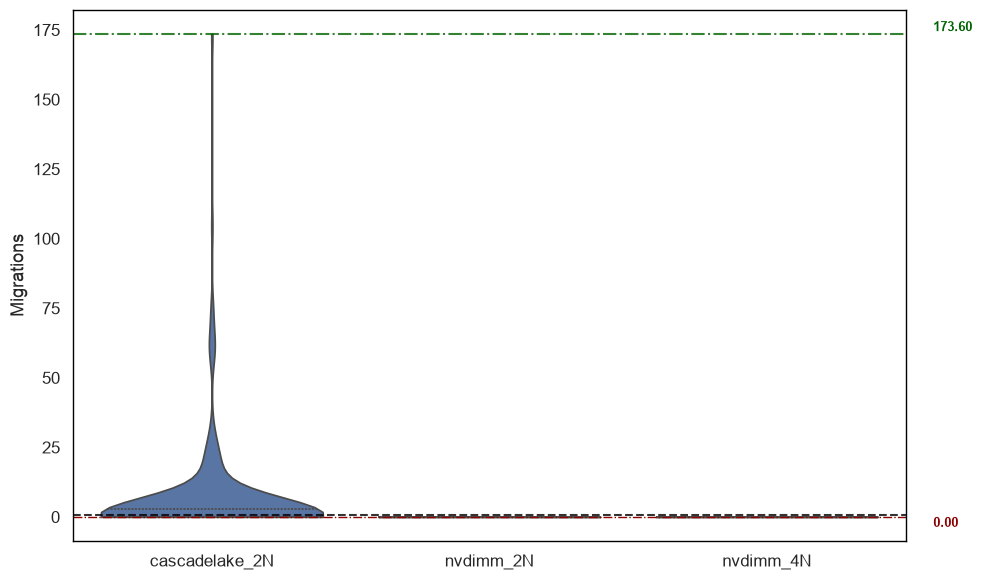

In [8]:
# Compute relative improvements using 1L as baseline

df_plot = df_summary.copy()

# Keep only the systems of interest
df_plot = df_plot[df_plot["system_name"].isin(["chameleon_cascade_lake_r", "chameleon_compute_nvdimm"])]
df_plot["system_name"] = df_plot["system_name"].replace({"chameleon_cascade_lake_r": "cascadelake", "chameleon_compute_nvdimm": "nvdimm"})
df_plot = df_plot.rename(columns={
    "runtime_data_pages_migrations_1L": "1L",
    "runtime_data_pages_migrations_1R": "1R",
    "runtime_data_pages_migrations_2A": "2A",
    "runtime_data_pages_migrations_2N": "2N",
    "runtime_data_pages_migrations_4A": "4A",
    "runtime_data_pages_migrations_4N": "4N",
})

# Melt for plotting
df_melt = pd.melt(
    df_plot,
    id_vars=["system_cores", "system_name", "workflow_instance"],
    value_vars=[
        # "1L",
        # "1R",
        # "2A",
        "2N",
        # "4A",
        "4N",
    ],
    var_name="metric",
    value_name="value"
)

# Label systems + metric clearly
df_melt["label"] = df_melt.apply(
    lambda x: f"{x['system_name']}_{x['metric'].replace('_norm','')}",
    axis=1
)

# Remove NaN (no 4N/1L for cascade_lake_r)
df_melt = df_melt.dropna(subset=["value"])

plot_violin_aggreg(df_melt, equal=0.5, perc="", rot=0)

In [9]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]    # boundaries for the 5 levels
labels = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

df_locality, locality_counts = assign_locality_levels(df_melt, column="value", bins=bins, labels=labels)
locality_counts

,Locality_Level,Count,Percentage
0,Very Low,433,83.109405
1,Low,3,0.575816
2,Medium,2,0.383877
3,High,2,0.383877
4,Very High,3,0.575816
